In [1]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [36]:
def filter_X(X: pd.DataFrame) -> pd.DataFrame:
    drop_qm_features = [
        'radius_of_gyration',
        'molecular_volume',
        # 'sterimol_L',
        # 'sterimol_Bmin',
        # 'sterimol_Bmax',
        'molecular_sasa',
        'solvation_energy_thf',
        'solvation_energy_cyclohexane',
        'solvation_energy_dmso',
        'avg_percentage_buried_volume',
        'min_percentage_buried_volume',
        'max_percentage_buried_volume',
        'std_percentage_buried_volume',
        'avg_atomic_sasa',
        'min_atomic_sasa',
        'max_atomic_sasa',
        'std_atomic_sasa',
        'min_partial_charge_thf',
        'max_partial_charge_thf',
        'std_partial_charge_thf',
        'min_partial_charge_cyclohexane',
        'max_partial_charge_cyclohexane',
        'std_partial_charge_cyclohexane',
        'min_partial_charge_dmso',
        'max_partial_charge_dmso',
        'std_partial_charge_dmso',
        'avg_bond_length',
        'min_bond_length',
        'max_bond_length',
        'std_bond_length',
        'avg_bond_stiffness',
        'min_bond_stiffness',
        'max_bond_stiffness',
        'std_bond_stiffness',
        'avg_effective_coordination_number',
        'min_effective_coordination_number',
        'max_effective_coordination_number',
        'std_effective_coordination_number'
    ]

    drop_topo_features = [
        'MaxPartialCharge',
        'MinPartialCharge',
        'MaxAbsPartialCharge',
        'MinAbsPartialCharge',
    ]
    
    return X.drop(
        [
            "avg_atomic_quadrupole_principal_invariant_3",  # quadrupole principal invariant 3 features correlate highly with the invariant 2 features, so can drop them
            "max_atomic_quadrupole_principal_invariant_3",
            "molecular_quadrupole_principal_invariant_3",
            "avg_atomic_dipole_dipole_interaction",  # the dipole dipole interaction between atoms would physically not be that influential on the solubility, can drop it
        ] + drop_qm_features + drop_topo_features,
        axis=1,
    )

In [37]:
def get_high_corr(X):
    corr_matrix = X.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    return (
        upper.unstack()
        .dropna()
        .sort_values(ascending=False)
    )

In [38]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [39]:
df.columns

Index(['id', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'canon_smiles', 'solubility'],
      dtype='str', length=354)

In [40]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)
X_filtered = filter_X(X)

In [41]:
high_corr = get_high_corr(X_filtered)

There seem to be quite a lot of features that correlate perfectly with each other (Pearson correlation of 1). There also seem to be some features that essentially say the same thing, like MolWt and ExactMolWt. As they serve no purpose besides increasing the amount of dimensions of our data, we can remove them. 

In [42]:
energy_corr = X_filtered.corr()["std_nuclear_repulsion"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(50)

std_nuclear_repulsion                          1.000000
std_atomic_polarizability_anisotropy           0.855196
max_nuclear_repulsion                          0.807849
std_atomic_polarizability_mean                 0.722240
avg_atomic_polarizability_mean                 0.714797
std_atomic_dipole_norm                         0.631460
BCUT2D_MWHI                                    0.603350
avg_atomic_dipole_norm                         0.576067
min_atomic_polarizability_mean                 0.550414
BCUT2D_MRHI                                    0.510461
avg_nuclear_repulsion                          0.507197
SlogP_VSA12                                    0.497661
std_atomic_fukui_plus                          0.455888
ir_centroid_freq_1500                          0.428550
avg_overlap_integral                           0.413787
max_atomic_dipole_norm                         0.412070
SMR_VSA10                                      0.394377
min_atomic_quadrupole_principal_invariant_3    0

In [49]:
energy_corr = X_filtered.corr()["molecular_dipole_norm"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(25)

molecular_dipole_norm           1.000000
max_partial_charge_water        0.544464
max_partial_charge              0.538855
ionization_energy               0.536039
gibbs_free_energy_300K_range    0.472394
enthalpy_range                  0.472093
std_enthalpy                    0.467573
std_energy                      0.458179
std_gibbs_free_energy_300K      0.457511
chemical_potential              0.426795
energy_range                    0.420067
delta_energy                    0.418730
TPSA                            0.410217
fr_COO                          0.398616
fr_COO2                         0.398041
heat_capacity_300K_range        0.380217
homo_lumo_gap                   0.378582
std_heat_capacity_300K          0.375965
MaxEStateIndex                  0.373766
MaxAbsEStateIndex               0.373741
NOCount                         0.367477
EState_VSA10                    0.362238
std_partial_charge_water        0.352160
std_partial_charge              0.347049
solvation_energy

Index(['delta_entropy_300K', 'entropy_300K_range', 'std_entropy_300K',
       'delta_heat_capacity_300K', 'heat_capacity_300K_range',
       'std_heat_capacity_300K', 'std_bond_energy', 'min_overlap_integral',
       'avg_atomic_charge_dipole_interaction',
       'std_atomic_charge_dipole_interaction',
       'avg_atomic_charge_quadrupole_interaction',
       'std_atomic_charge_quadrupole_interaction',
       'avg_atomic_dipole_dipole_interaction',
       'std_atomic_dipole_dipole_interaction', 'SMR_VSA8', 'SlogP_VSA9'],
      dtype='str')


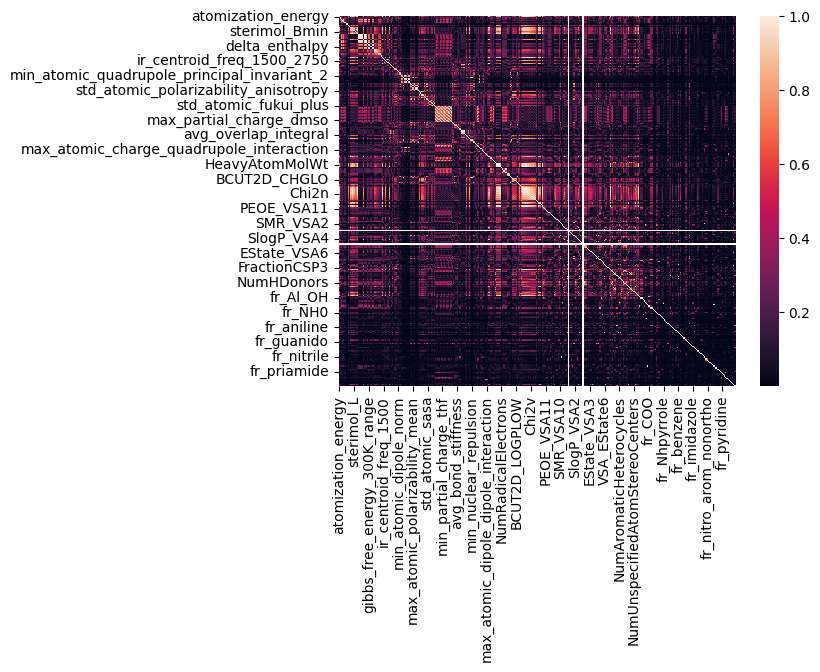

In [43]:
corr = X.corr().abs()

sns.heatmap(corr)
print(X.columns[X.std() < 0.01])

The Pearson correlation plot reveals there are two features that correlate with 0 other features: `"SMR_VSA8"` and `"SlogP_SVA9"`. This is because these features are constant. They can be removed as they provide zero information to the model.

In [45]:
corr_target = X_filtered.corrwith(y).abs().sort_values(ascending=True)
# corr_target.filter(regex="dipole")
corr_target[corr_target < 0.01]

PEOE_VSA12                                     0.000071
max_atomic_quadrupole_principal_invariant_2    0.000200
BCUT2D_LOGPLOW                                 0.000248
NumRadicalElectrons                            0.000383
fr_C_S                                         0.000895
fr_Nhpyrrole                                   0.001402
fr_Ar_NH                                       0.001402
fr_sulfide                                     0.002132
fr_Ndealkylation2                              0.002371
avg_atomic_polarizability_anisotropy           0.002432
fr_diazo                                       0.002698
NumBridgeheadAtoms                             0.003633
max_atomic_polarizability_mean                 0.003685
ir_norm_intensity_2750_4000                    0.003714
VSA_EState9                                    0.003738
std_atomic_quadrupole_principal_invariant_3    0.003757
avg_nuclear_repulsion                          0.006363
fr_alkyl_carbamate                             0

In [50]:
corr_target.filter(regex="dipole")

min_atomic_dipole_dipole_interaction    0.010497
molecular_dipole_norm                   0.012698
max_atomic_dipole_dipole_interaction    0.016477
std_atomic_dipole_norm                  0.030699
max_atomic_dipole_norm                  0.037619
max_atomic_charge_dipole_interaction    0.108097
min_atomic_charge_dipole_interaction    0.124976
avg_atomic_charge_dipole_interaction    0.177335
avg_atomic_dipole_norm                  0.242044
min_atomic_dipole_norm                  0.247503
std_atomic_dipole_dipole_interaction    0.283279
std_atomic_charge_dipole_interaction    0.365911
dtype: float64